In [3]:
from superfv import HydroSolver, ics, RiemannSolver
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams["font.size"] = 15

In [4]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['41.96GB', '42.41GB']


In [5]:
base_directory = "/scratch/gpfs/jp7427/FVvsSD/square2d/"

In [12]:
def run_superfv_sim(name, p, N, **kwargs):
    sim = HydroSolver(
        ic=partial(ics.square, vx=2.0, vy=1.0),
        rho_min=1e-10,
        P_min=1e-10,
        nx=N,
        ny=N,
        p=p,
        cupy=True,
        # output_path=path,
        **kwargs,
    )
    sim.run(1.0)
    return sim

In [ ]:
# def run_spd_sim(name, p, NDOF, **kwargs):
#     def square_wave(xy: np.ndarray, case: int, vx, vy, P):
#         x = xy[0]
#         y = xy[1]
#         if case == 0:
#             # density
#             inside_square = np.logical_and(np.abs(x - 0.5) < 0.25, np.abs(y - 0.5) < 0.25)
#             return np.where(inside_square, 2.0, 1.0)
#         elif case == 1:
#             # vx
#             return vx * np.ones(x.shape)
#         elif case == 2:
#             # vy
#             return vy * np.ones(x.shape)
#         elif case == 4:
#             # Pressure
#             return P * np.ones(x.shape)
#         else:
#             return np.zeros(x.shape)
    
#     sim = SPD_Simulator(
#         p=p,
#         N=(NDOF // (p + 1), NDOF // (p + 1)),
#         init_fct=partial(sine_wave, vx=2.0, vy=1.0, P=1.0),
#         cfl_coeff=0.4,
#         use_cupy=True,
#         time_integrator="rk3",
#         scheme="SD",
#         FB=False,
#         **kwargs,
#     )

#     sim.perform_time_evolution(1.0)
#     return sim
        

In [21]:
def plot_fv(ax, sim, **kwargs):
    ax.set_aspect("equal")

    x_fv, y_fv, _ = sim.mesh.centers
    z_fv = sim.snapshot_history[-1].w[0, :, :, 0].T
    nx, ny = z_fv.shape
    return ax.plot(cp.asnumpy(x_fv), z_fv[:, ny // 2], **kwargs)


def plot_sd(ax, sim):
    ax.set_aspect("equal")

    x_sd = sim.regular_faces()[0]
    y_sd = sim.regular_faces()[1]
    z_sd = sim.transpose_to_fv(sim.regular_mesh(sim.dm.W_cv))[0]
    return ax.pcolormesh(x_sd, y_sd, z_sd)

In [24]:
s1 = run_superfv_sim("", 7, 128, riemann_solver=RiemannSolver.LLF)
s2 = run_superfv_sim("", 7, 128, riemann_solver=RiemannSolver.HLLC)

SuperFV: 879 steps | t=1.00e+00/1.00e+00, dt=2.33e-04 | rho_min=9.04e-01 | E_cons=0.00e+00 | wall=3.91e+00s (done)
SuperFV: 880 steps | t=1.00e+00/1.00e+00, dt=8.80e-04 | rho_min=8.97e-01 | E_cons=0.00e+00 | wall=4.04e+00s (done)


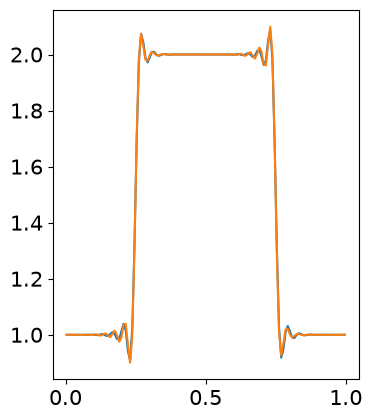

In [27]:
fig, ax = plt.subplots()

plot_fv(ax, s1)
plot_fv(ax, s2)